In [1]:
from datetime import datetime
from math import cos, radians, cos, sqrt
from pathlib import Path
from typing import List, NamedTuple, Tuple

import pandas as pd
import pybase64
import pydeck
from visionapi.sae_pb2 import PositionMessage
from visionapi.common_pb2 import MessageType, TypeMessage
from visionlib.saedump import DumpMeta, Event, message_splitter


class GPSPoint(NamedTuple):
    timestamp: datetime
    lat: float
    lon: float
    speed: float = 0.0

    def to_coord_tuple(self) -> Tuple[float, float]:
        return (self.lat, self.lon)

class LineSegment(NamedTuple):
    start_lat: float
    start_lon: float
    end_lat: float
    end_lon: float

class Track(NamedTuple):
    source_file: Path
    gps_points: List[GPSPoint]

def parse_file_into_tracks(dump_file: Path, stream_filter: str = None) -> List[Track]:
    tracks = []
    track_points = []
    prev_timestamp = 0
    with open(dump_file, 'r') as f:
        message_iter = message_splitter(f)
        start_message = next(message_iter)
        dump_meta = DumpMeta.model_validate_json(start_message)

        for message in message_iter:
            event = Event.model_validate_json(message)
            if stream_filter and event.meta.source_stream != stream_filter:
                continue

            proto_bytes = pybase64.standard_b64decode(event.data_b64)

            position_msg = PositionMessage()
            position_msg.ParseFromString(proto_bytes)

            if not position_msg.fix:
                continue

            if position_msg.timestamp_utc_ms - prev_timestamp > 2000 and len(track_points) > 0:
                tracks.append(Track(source_file=dump_file, gps_points=track_points))
                track_points = []

            prev_timestamp = position_msg.timestamp_utc_ms

            track_points.append(GPSPoint(
                timestamp=datetime.fromtimestamp(position_msg.timestamp_utc_ms / 1000), 
                lat=position_msg.geo_coordinate.latitude, 
                lon=position_msg.geo_coordinate.longitude
            ))
    
    if len(track_points) > 0:
        tracks.append(Track(source_file=dump_file, gps_points=track_points))

    return tracks

def track_to_line_segments(track: Track) -> List[LineSegment]:
    segments = []
    for i in range(len(track.gps_points) - 1):
        segments.append(LineSegment(
            start_lat=track.gps_points[i].lat,
            start_lon=track.gps_points[i].lon, 
            end_lat=track.gps_points[i+1].lat,
            end_lon=track.gps_points[i+1].lon
        ))
    return segments

def moving_average(points: List[GPSPoint], window_size: int) -> List[GPSPoint]:
    smoothed_points = []
    for i in range(len(points)):
        start_index = max(0, i - window_size + 1)
        window_points = points[start_index:i+1]
        avg_lat = sum(p.lat for p in window_points) / len(window_points)
        avg_lon = sum(p.lon for p in window_points) / len(window_points)
        smoothed_points.append(GPSPoint(timestamp=points[i].timestamp, lat=avg_lat, lon=avg_lon))
    return smoothed_points

def exponential_sliding_window(points: List[GPSPoint], alpha: float) -> List[GPSPoint]:
    smoothed_points = []
    prev_lat = points[0].lat
    prev_lon = points[0].lon
    for p in points:
        smoothed_lat = alpha * p.lat + (1 - alpha) * prev_lat
        smoothed_lon = alpha * p.lon + (1 - alpha) * prev_lon
        smoothed_points.append(GPSPoint(timestamp=p.timestamp, lat=smoothed_lat, lon=smoothed_lon))
        prev_lat, prev_lon = smoothed_lat, smoothed_lon
    return smoothed_points

def calculate_distance_m(point1: GPSPoint, point2: GPSPoint) -> float:
    # First convert to a spatial coordinate system for accurate distance calculation
    # For simplicity, we'll use a rough approximation here (not suitable for large distances)
    lat_diff = (point2.lat - point1.lat) * 111320  # Approximate meters per degree latitude
    lon_diff = (point2.lon - point1.lon) * 111320 * cos(radians((point1.lat + point2.lat) / 2))  # Approximate meters per degree longitude
    distance = sqrt(lat_diff**2 + lon_diff**2)  # Distance in meters
    return distance
    
def calculate_speeds(points: List[GPSPoint]) -> List[GPSPoint]:
    speeds = []
    for i in range(len(points) - 1):
        distance = calculate_distance_m(points[i], points[i+1]) * 3.6  # Convert m/s to km/h
        time_diff = (points[i+1].timestamp - points[i].timestamp).total_seconds()  # Time difference in seconds
        if time_diff > 0:
            speed = distance / time_diff  # Speed in km/h
        else:
            speed = 0.0
        speeds.append(GPSPoint(timestamp=points[i].timestamp, lat=points[i].lat, lon=points[i].lon, speed=speed))
    return speeds

LOG_FILE = './position-source-was-pods.saedump'

tracks: List[Track] = parse_file_into_tracks(LOG_FILE, stream_filter='positionsource:was-pod01')
track = tracks[1]

df_track = pd.DataFrame(track_to_line_segments(track))

ground_truth_line = pydeck.Layer(
    'LineLayer',
    df_track,
    get_source_position='[start_lon, start_lat]',
    get_target_position='[end_lon, end_lat]',
    get_color='[100, 200, 100]',
    get_width=3,
)

moving_average_line = pydeck.Layer(
    'LineLayer',
    pd.DataFrame(track_to_line_segments(Track(source_file=track.source_file, gps_points=moving_average(track.gps_points, window_size=5)))),
    get_source_position='[start_lon, start_lat]',
    get_target_position='[end_lon, end_lat]',
    get_color='[100, 100, 200]',
    get_width=3,
)

exponential_sliding_window_line = pydeck.Layer(
    'LineLayer',
    pd.DataFrame(track_to_line_segments(Track(source_file=track.source_file, gps_points=exponential_sliding_window(track.gps_points, alpha=0.3)))),
    get_source_position='[start_lon, start_lat]',
    get_target_position='[end_lon, end_lat]',
    get_color='[100, 100,200]',
    get_width=3,
)

exponential_sliding_window_scatter = pydeck.Layer(
    'ScatterplotLayer',
    pd.DataFrame(exponential_sliding_window(track.gps_points, alpha=0.3)),
    get_position='[lon, lat]',
    get_color='[100, 100, 200]',
    get_radius=0.24
)

smoothed_speed_line = pydeck.Layer(
    'LineLayer',
    pd.DataFrame(track_to_line_segments(Track(source_file=track.source_file, gps_points=calculate_speeds(exponential_sliding_window(track.gps_points, alpha=0.3))))),
    get_source_position='[start_lon, start_lat]',
    get_target_position='[end_lon, end_lat]',
    get_color='[speed * 4, speed * 4, 200]',
    get_width=3,
)

ground_truth_scatter = pydeck.Layer(
    'ScatterplotLayer',
    df_track,
    get_position='[start_lon, start_lat]',
    get_color='[255, 0, 0]',
    get_radius=0.24
)

view_state = pydeck.data_utils.compute_view(df_track[['start_lon', 'start_lat']].values.tolist())
pydeck.Deck(
    layers=[
        ground_truth_scatter,
        # ground_truth_line,
        # moving_average_line,
        # exponential_sliding_window_line,
        # exponential_sliding_window_scatter,
        smoothed_speed_line,
    ], 
    initial_view_state=view_state,
    height=800,
).to_html(notebook_display=True, iframe_height=800)

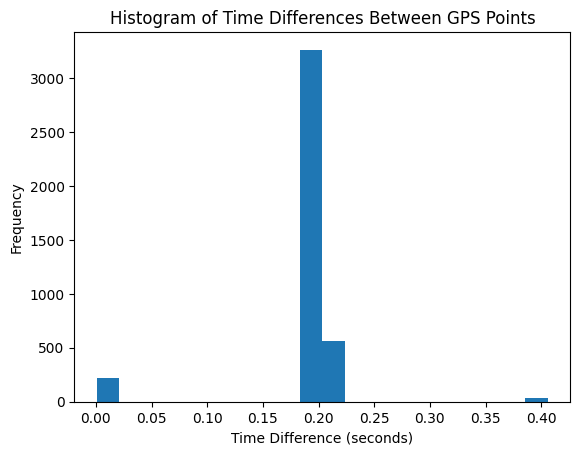

In [2]:
import matplotlib.pyplot as plt

def get_time_diff(track: Track) -> List[float]:
    time_diffs = []
    for i in range(len(track.gps_points) - 1):
        time_diff = (track.gps_points[i+1].timestamp - track.gps_points[i].timestamp).total_seconds()
        time_diffs.append(time_diff)
    return time_diffs

# Plot time differences between GPS points
pd.DataFrame(track_to_line_segments(track))
time_diffs = get_time_diff(track)
plt.hist(time_diffs, bins=20)
plt.xlabel('Time Difference (seconds)')
plt.ylabel('Frequency')
plt.title('Histogram of Time Differences Between GPS Points')
plt.show()